In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister # import quantum circuit component 
from qiskit.visualization import plot_histogram # visualizing results
from qiskit_aer import AerSimulator # Simulates quantum circuit on the backend
import ipywidgets as widgets # creates interactive widgets 
from IPython.display import display # displays the widgets 


button_p = widgets.Button(description='Play') # this creates the button that starts the game

# creates the drop down menu for human 
gate_p = widgets.Dropdown( 
    options=[('Identity', 'i'), ('Bit Flip', 'x')], # provides options for huaman to play 
    description='Choice:', # name for the drop down 
    disabled=False # This keeps the drop down enabled 
)
out_p = widgets.Output() # this is the output widget to display the results 


# Main game 
def on_button_clicked(b): # This executes the games once the button is pressed
    with out_p: # puts all output on the output widget 
        out_p.clear_output()  # Clear previous outputs

        # Create quantum and classical registers
        qreg = QuantumRegister(1, 'q') #creates a quantum register with 1 qubit named q 
        creg = ClassicalRegister(1, 'c') #creates a classical register with 1 bit named c 
        qc = QuantumCircuit(qreg, creg) #creates a quantum circuit with both 

        # Turn 1: Hadamard gate on qubit 
        qc.h(qreg[0])

        # Turn 2: Apply gate based on user selection
        if gate_p.value == 'i': #if human chooses Identity matrix 
            qc.id(qreg[0]) # apply identity or basically do nothing
        elif gate_p.value == 'x': # if doesnt chose I choses the bit flip 
            qc.x(qreg[0]) # apply X gate or bit flip 

        # Turn 3: Final Hadamard
        qc.h(qreg[0])

        # Measurement
        qc.measure(qreg, creg) # mesasure the qubit, store in creg

        # Simulate
        simulator = AerSimulator() # creates a simulator to run quantum circuit
        job = simulator.run(qc, shots=8192) # job to run the circuit 8192 times
        result = job.result() # get result from simulation
        counts = result.get_counts() # count how many times each measurement was recorded 

        # Output Result
        print("Measurement results:", counts) #print a string and the counts 
        if counts.get('0', 0) == 8192: # if all measuremetns = 0 
            print("You Lose to Quantum. Quantum Computer Wins") # print comp wins
        elif counts.get('1', 0) == 8192: # if all measruements are 1 
            print("You Win against Quantum Computer") # print human wins 
        else:
            print("Either Quantum or You Wins") # this is if there is a mix of 0 or 1 print the string

button_p.on_click(on_button_clicked) #connects the button click to the game 

# Display UI
display(widgets.VBox([gate_p, button_p, out_p])) #just displays the whole interface to the player in Jupyter notebook 

In [ ]:
#All necesecary imports as before...
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import ipywidgets as widgets
from IPython.display import display

In [3]:
# Building the initial circuit

def initial_circuit(): # creates and returns a quant circuit
    circuit = QuantumRegister(1, 'circuit') # a quantum register named circuit, the qreg holds one qubit called circuit
    measure = ClassicalRegister(1, 'result') # a creg named measrue, the creq has 1 bit named result 
    qc = QuantumCircuit(circuit, measure) # creates the quantum circuit using the initlaized qreg and creg
    qc.draw('mpl') # this function draws the circuit
    return qc, circuit, measure # returns the qc and the two registers for use later


In [4]:
# Widget Initialization

gate = widgets.Dropdown( #creates the widget drop down for user
    options=[('Identity', 'i'), ('Bit Flip', 'x')], #provides various options
    description='Choice: ', # this is the text next to the drop down letting the user know they have a choice 
    disabled=False, # keep the drop down enabled so it can be used 
)

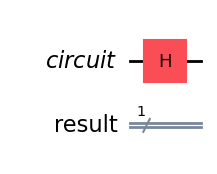

In [5]:
# Unpack all three returned values from the initial circuit function
qc, circuit, measure = initial_circuit()

# Now you can use them
qc.h(circuit[0]) #apply a hadamard gate to the first qubit
qc.draw('mpl') # draw the quantum circuit

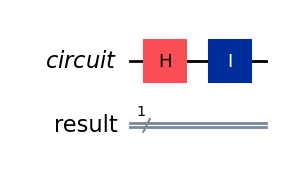

In [6]:
if gate.value == 'i': # check if the slected gate value is i 
    qc.id(circuit[0]) # if so apply the Identity 
if gate.value == 'x': # check if the slected gate value is x
    qc.x(circuit[0]) # if so apply the bit flip 

qc.draw('mpl') # draw circuit

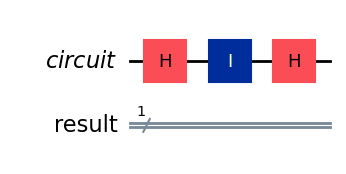

In [ ]:
# Used H Gate

qc.h(circuit[0]) #apply another hadamard gate 
qc.draw('mpl') # draw circuit

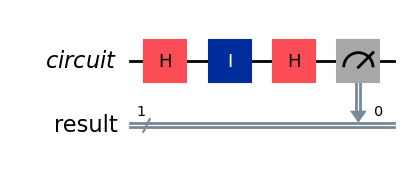

In [ ]:
qc.measure(circuit, measure) # measure all qubits in the qreg 'circuit' and store in creg 'measure'
qc.draw('mpl') # draw circuit

{'0': 8192}
Probabilities: {'0': 1.0}


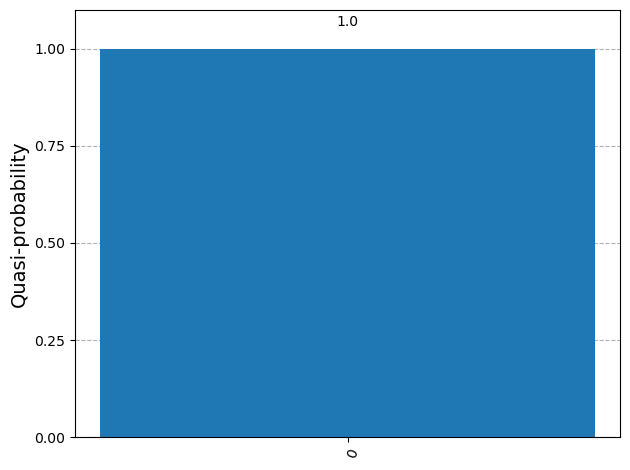

In [ ]:

# Create the circuit in this scope
qc, circuit, measure = initial_circuit()  # Unpack all three returned values from the initial circuit function
qc.h(circuit[0]) #apply a hadamard on first qubit

# Apply the selected gate
if gate.value == 'i':
    qc.id(circuit[0])
elif gate.value == 'x':
    qc.x(circuit[0])

qc.h(circuit[0]) # apply another hadamard 
qc.measure(circuit, measure) #measure and store 

# Run simulation using qiskits AerSimulator
backend = AerSimulator() 
job = backend.run(qc, shots=8192) # runs the circuit 8192 times 
res = job.result().get_counts() # counting the result of running the circuit 8192 times 
print(res) # print the results 

# Convert counts to probabilities
total_shots = sum(res.values()) # total shots should be equal to sum or results
probabilities = {state: count/total_shots for state, count in res.items()} # converts coutns to probabilites by dividing each count by total number of shots 
print("Probabilities:", probabilities) # print the probabilites 

plot_histogram(probabilities) # plot using matplotlib

In [ ]:
if len(res) == 1 and list(res.keys())[0] == '0': # if theres on solution and that solution is '0'
    print("Quantum Computer Wins") # print computer wins 
if len(res) == 1 and list(res.keys())[0] == '1': # if theres on soltuion and its '1'
    print("Classical Human Wins") # print human wins 
if len(res) == 2: # if there are two different solutions ie '1' and '0' 
    print("Either Quantum Computer or Classical Human Wins") # print either 

Quantum Computer Wins


Testing connection...
Connected! Available backends: ['ibm_brisbane', 'ibm_sherbrooke']
Submitting job to ibm_brisbane using SamplerV2...


/opt/miniconda3/envs/qenv310/lib/python3.10/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1129: UserWarning: IBM Quantum Platform is moving, and this version will be sunset on July 1. To get started on the new platform, read the migration guide at https://docs.quantum.ibm.com/migration-guides/classic-iqp-to-cloud-iqp
  warnings.warn(warning_message)


Job ID: d1c8tktv3z50008ahsk0
Waiting for job to complete...
Results: {'0': 8192}


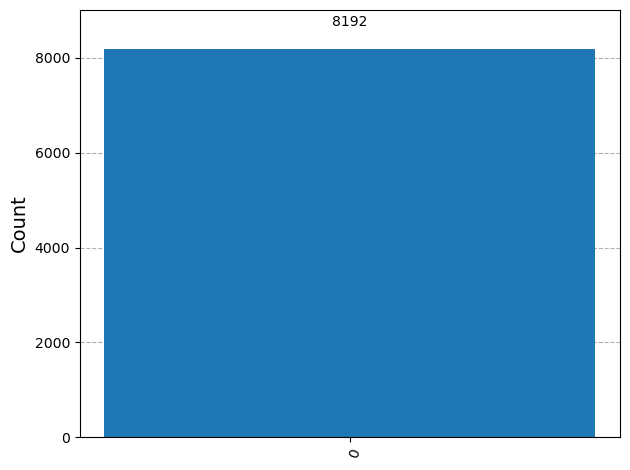

In [ ]:
## Had to enlist some help from AI as I was having trouble connecting to my IBM accout
## but i was able to figure it out with some help 


#all neccessary imports
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit import transpile
from qiskit.visualization import plot_histogram
import warnings

# Suppress the deprecation warning for now this keeps output clean 
warnings.filterwarnings("ignore", category=DeprecationWarning)

service = QiskitRuntimeService( # accessing the service through IBM 
    channel="ibm_quantum", # specifies which channel, my API token on line below
    token="cb27202768405cd33c8f058353c45b7ae5da33e111b2140b563f513662d2aa896b1ab69bb5221384f6fdf62b0b8812c5b8c9cd912e63307bc5910866dc4c6e7f"  
)

print("Testing connection...") # indicate that coneection is starting 
try:
    backends = service.backends() # shows me what backends are available 
    print(f"Connected! Available backends: {[b.name for b in backends]}") # print what backends are available 
except Exception as e:
    print(f"Connection failed: {e}") # print error message if connection fails
    print("Please check your API token and try again.")
    raise

# Get a real backend
backend_real = service.backend('ibm_brisbane')  # select ibm brisbane 

# Transpile your quantum circuit for the specific backend
# Make sure 'qc' is your quantum circuit variable
qc_transpiled = transpile(qc, backend_real)

# Use the new Sampler primitive interface (Qiskit 2.0+ way)
print(f"Submitting job to {backend_real.name} using SamplerV2...") # just shows what backend the job is being submitted to 
sampler = SamplerV2(mode=backend_real) # initialize a SamplerV2 object called 'sampler' to run circuits on a selected backend 

# Run the job with the sampler
job_real = sampler.run([qc_transpiled], shots=8192)

print(f"Job ID: {job_real.job_id()}") #print job Id that can be seen on IBM website
print("Waiting for job to complete...") 

# Get results - SamplerV2 returns different format
result = job_real.result()
# The actual data is in the 'result' attribute
pub_result = result[0]  # First (and only) circuit result
counts = pub_result.data.result.get_counts() # get the measurement counts from circuit results should have bit strings and coutn values

print("Results:", counts) # print measured counts 
plot_histogram(counts) # plot resutls 